# Análisis de Fourier paso a paso

Este cuaderno acompaña a la presentación 3.0 y reproduce, paso a paso, la [página interactiva](https://jtorreci.github.io/calculo_dinamico/fourier/) de la misma sesión. En el cálculo dinámico de estructuras la carga rara vez es un seno puro; sin embargo, cualquier carga periódica puede escribirse como una suma de senos y cosenos cuyas frecuencias son múltiplos de la fundamental. Dado que la respuesta de un oscilador lineal a cada armónico es conocida, esta descomposición permite obtener la respuesta a una carga arbitraria por superposición.

En primer lugar se definen las integrales que dan los coeficientes y se programan tal y como se escriben (regla del trapecio). Posteriormente se aplican a un seno, a una suma de senos y a una señal pseudoaleatoria, y se reconstruye esta última con un número creciente de armónicos. Por último, se comprueba que la transformada rápida de Fourier (FFT, *Fast Fourier Transform*) da los mismos coeficientes con un coste mucho menor.

El código reutilizable está en `fourier.py`, organizado en tres capas: la de cálculo contiene funciones puras, la de proceso construye los casos y los barridos, y la de dibujo solo representa resultados ya calculados. Las celdas del cuaderno se limitan a llamar a esas funciones.

## DATOS — modifique aquí

Todos los parámetros del cuaderno se fijan en la celda siguiente. Tras cambiar cualquiera de ellos se vuelven a ejecutar todas las celdas (*Run All*).

In [1]:
import numpy as np

# --- DATOS — modifique aquí ---------------------------------------------------
M = 4096                      # intervalos de integración por periodo (≥ 2048; 4096 como la página)

# Paso 1: un seno
T_SENO = 2.0                  # periodo de análisis [s]
F_SENO = 1.0                  # frecuencia del seno [Hz]  -> armónico n = F_SENO·T_SENO
N_MAX_SENO = 12               # armónicos que se calculan
T_FUGA = 1.75                 # periodo de análisis que no abarca un número entero de ciclos [s]

# Paso 2: suma de senos  f = Σ A sen(2π f t + φ)  (o cos)
T_SUMA = 2.0                  # [s]
COMPONENTES = [
    {"amplitud": 1.00, "frecuencia": 1.0, "fase": 0.0,       "tipo": "sen"},
    {"amplitud": 0.50, "frecuencia": 3.0, "fase": np.pi / 4, "tipo": "sen"},
    {"amplitud": 0.25, "frecuencia": 5.0, "fase": 0.0,       "tipo": "cos"},
]
N_MAX_SUMA = 16

# Paso 3: señal pseudoaleatoria (idéntica a la de la página interactiva)
T_ALEATORIA = 2.0             # [s]
N_NODOS = 32                  # valores del generador congruencial
SEMILLA = 12345               # x_0
N_MAX_ALEATORIA = 64

# Paso 4: reconstrucción
LISTA_N_REJILLA = [1, 2, 4, 8, 16, 32, 64]
USAR_WIDGETS = True           # False: solo figuras estáticas

In [2]:
%matplotlib inline
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import fourier as fu

## 0. Las integrales

Se considera una señal $f(t)$ periódica de periodo $T$, es decir, tal que $f(t+T)=f(t)$ para todo $t$. Su serie de Fourier la aproxima por una suma de armónicos de frecuencias múltiplos de la fundamental $2\pi/T$:

$$
f(t) \approx \frac{a_0}{2} + \sum_{n=1}^{N}\left[a_n\cos(\omega_n t) + b_n\sin(\omega_n t)\right],
\qquad \omega_n = \frac{2\pi n}{T},
$$

donde $N$ es el número de armónicos retenidos y $a_n$, $b_n$ son los coeficientes de Fourier. Cada coeficiente mide cuánto se parece la señal al coseno o al seno de frecuencia $\omega_n$, y se obtiene multiplicando por ese armónico e integrando en un periodo:

$$
a_n = \frac{2}{T}\int_0^T f(t)\cos(\omega_n t)\,dt, \qquad
b_n = \frac{2}{T}\int_0^T f(t)\sin(\omega_n t)\,dt .
$$

El término $a_0/2$ es, por tanto, el valor medio de la señal. La justificación está en la ortogonalidad de senos y cosenos en un periodo: el producto de dos armónicos distintos tiene área nula, de modo que la integral «filtra» un único término de la serie.

Cada pareja $(a_n, b_n)$ puede escribirse también como una amplitud y una fase:

$$
a_n\cos(\omega_n t) + b_n\sin(\omega_n t) = A_n\sin(\omega_n t + \theta_n),
\qquad A_n = \sqrt{a_n^2+b_n^2}, \qquad \theta_n = \operatorname{atan2}(a_n, b_n),
$$

lo que conduce al espectro de amplitudes $A_n$ frente a la frecuencia $n/T$ (en hercios), que es la representación que se usa en el resto del cuaderno.

Las integrales se evalúan con la regla del trapecio sobre $M$ intervalos iguales de $[0,T]$ (`fu.coeficientes_integral`), sin ningún atajo. La FFT se deja para el paso 5, una vez comprobado qué calcula.

In [3]:
import inspect
print(inspect.getsource(fu.coeficientes_integral))

def coeficientes_integral(t, f, n_max):
    """a_n y b_n (n = 0..n_max) por la regla del trapecio, literalmente.

        a_n = (2/T) ∫_0^T f cos(w_n t) dt,   b_n = (2/T) ∫_0^T f sen(w_n t) dt

    ``t`` es la malla de [0, T] con extremos incluidos (``malla_periodo``).
    """
    T = t[-1] - t[0]
    a = np.zeros(n_max + 1)
    b = np.zeros(n_max + 1)
    for n in range(n_max + 1):
        w = frecuencia_armonico(n, T)
        a[n] = 2.0 / T * np.trapezoid(f * np.cos(w * t), t)
        b[n] = 2.0 / T * np.trapezoid(f * np.sin(w * t), t)
    return a, b



## 1. Un seno

El primer caso es el más sencillo posible: $f(t)=\sin(2\pi\cdot 1\cdot t)$ analizada con $T = 2$ s. En ese intervalo caben exactamente dos ciclos, por lo que la señal coincide con el armónico $n = 2$ ($\omega_2 = 2\pi$ rad/s) y todos los demás coeficientes deberían anularse.

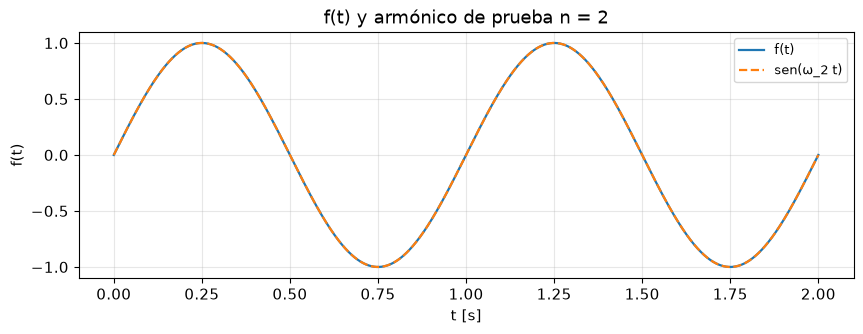

In [4]:
seno = fu.caso_seno(T_SENO, F_SENO, M, N_MAX_SENO)
n_seno = int(round(F_SENO * T_SENO))
prueba = fu.producto_con_armonico(seno, n_seno, "sen")
fig = fu.dibujar_senal(seno, extra=[(seno["t"], prueba["base"], f"sen(ω_{n_seno} t)")],
                       titulo=f"f(t) y armónico de prueba n = {n_seno}")

El producto $f(t)\sin(\omega_n t)$ contiene toda la información del coeficiente $b_n$: su área en el periodo, multiplicada por $2/T$, es el propio coeficiente. Con $n = 2$ el producto es $\sin^2$ y el área es siempre positiva; con $n = 3$ las zonas positivas (verde) y negativas (rojo) se compensan exactamente.

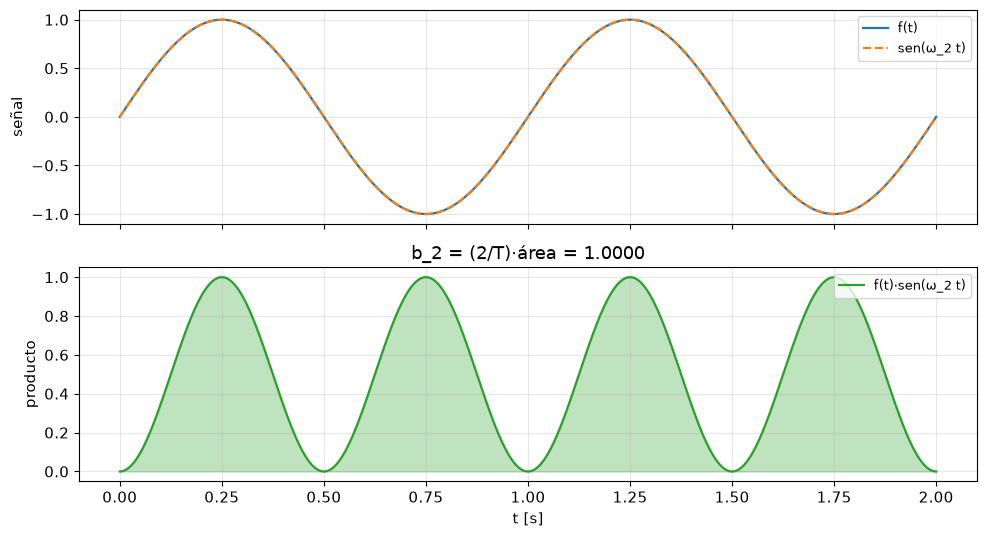

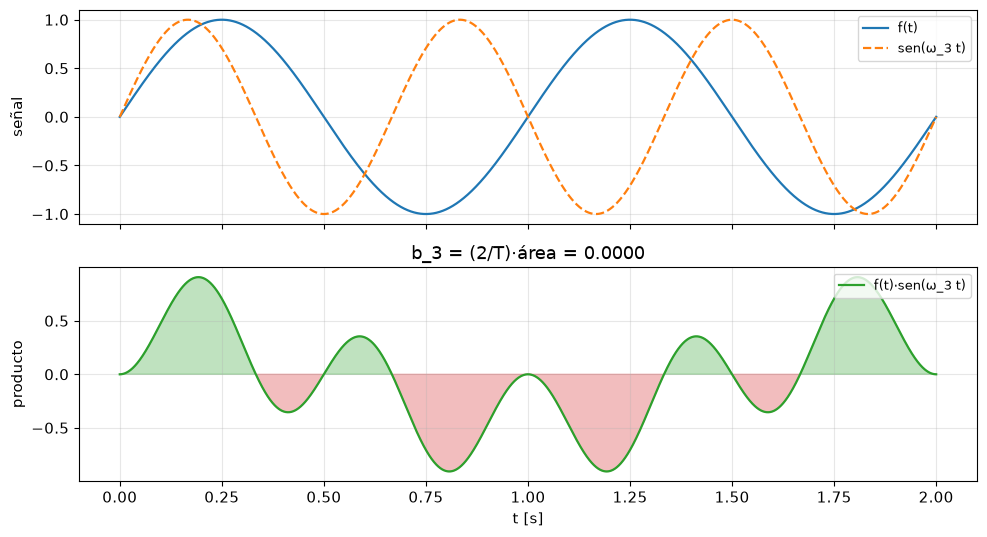

In [5]:
for n in (n_seno, n_seno + 1):
    fig = fu.dibujar_producto(seno, fu.producto_con_armonico(seno, n, "sen"))

Al repetir la integral para $n = 0, 1, \dots, 12$ se obtiene el diagrama de barras siguiente. Solo sobrevive $b_2 = 1$; el resto de los coeficientes son del orden del error de redondeo, lo que quiere decir que la ortogonalidad se conserva también en la versión discreta de la integral.

n =  0   a_n = -5.55e-17   b_n =  0.000000
n =  1   a_n =  0.00e+00   b_n = -0.000000
n =  2   a_n =  0.00e+00   b_n =  1.000000
n =  3   a_n =  0.00e+00   b_n =  0.000000
n =  4   a_n =  1.39e-17   b_n = -0.000000
n =  5   a_n =  2.08e-17   b_n = -0.000000
n =  6   a_n =  0.00e+00   b_n =  0.000000
n =  7   a_n = -6.94e-18   b_n =  0.000000
n =  8   a_n = -3.82e-17   b_n =  0.000000
n =  9   a_n =  2.43e-17   b_n = -0.000000
n = 10   a_n =  1.39e-17   b_n = -0.000000
n = 11   a_n = -1.04e-17   b_n = -0.000000
n = 12   a_n =  1.04e-17   b_n =  0.000000


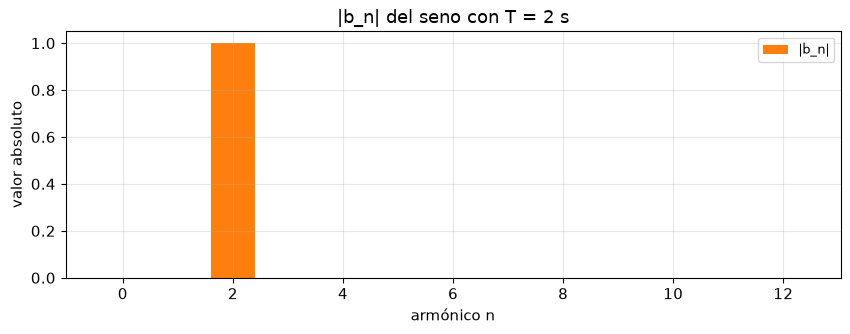

In [6]:
fig = fu.dibujar_coeficientes(seno, cuales=("b",), titulo="|b_n| del seno con T = 2 s")
for n in seno["n"]:
    print(f"n = {n:2d}   a_n = {seno['a'][n]: .2e}   b_n = {seno['b'][n]: .6f}")

**Ejercicio 1.1 (fuga espectral).** Indíquese qué ocurre si el periodo de análisis no contiene un número entero de ciclos, por ejemplo $T = 1{,}75$ s (variable `T_FUGA`). La celda siguiente repite el cálculo con ese periodo. La serie de Fourier supone que la ventana se repite indefinidamente, de modo que aparece un salto en $t = T$ y la energía del seno se reparte entre varios armónicos vecinos (*fuga espectral*, en inglés *leakage*).

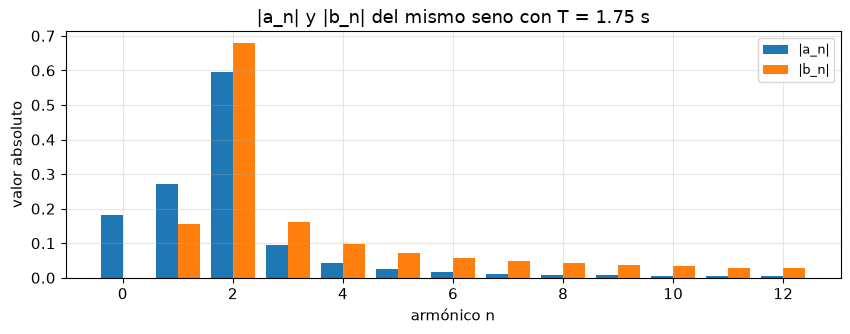

In [7]:
fuga = fu.caso_seno(T_FUGA, F_SENO, M, N_MAX_SENO)
fig = fu.dibujar_coeficientes(fuga, titulo=f"|a_n| y |b_n| del mismo seno con T = {T_FUGA} s")

## 2. Suma de senos

El segundo caso combina tres armónicos con amplitudes y fases distintas:

$$
f(t) = 1{,}0\,\sin(2\pi\cdot 1\cdot t) + 0{,}5\,\sin\!\left(2\pi\cdot 3\cdot t + \tfrac{\pi}{4}\right) + 0{,}25\,\cos(2\pi\cdot 5\cdot t),
$$

analizada de nuevo con $T = 2$ s. Dado que las integrales son lineales, cada término se recupera por separado: el espectro de amplitudes debe mostrar 1, 0,5 y 0,25 en 1, 3 y 5 Hz (armónicos 2, 6 y 10).

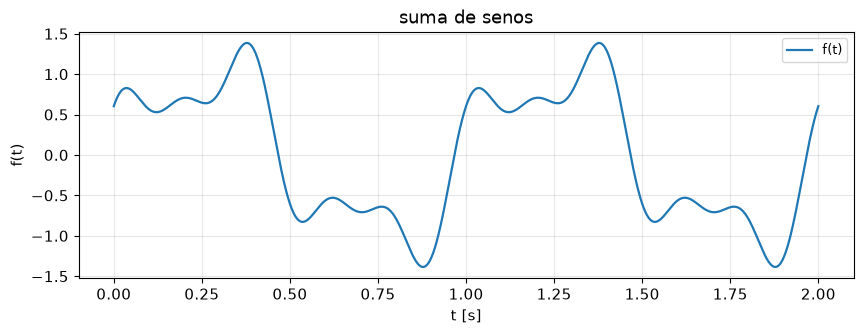

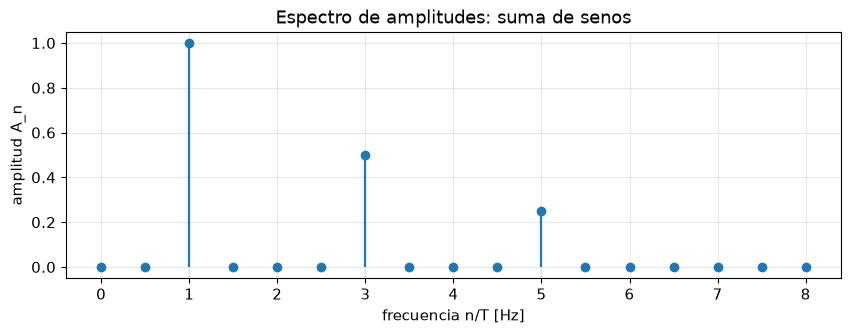

In [8]:
suma = fu.caso_suma_senos(T_SUMA, COMPONENTES, M, N_MAX_SUMA)
fig = fu.dibujar_senal(suma)
fig = fu.dibujar_espectro(suma)

La fase $\theta_n$ se obtiene con la convención $A_n\sin(\omega_n t + \theta_n)$, la misma de la página interactiva. Así, el seno puro tiene fase nula, el término $\sin(x + \pi/4)$ recupera directamente $\theta = \pi/4$ (45°) y el coseno, que equivale a $\sin(x + \pi/2)$, tiene $\theta = \pi/2$ (90°). La tabla siguiente lista los armónicos con amplitud apreciable.

In [9]:
print(" n   f [Hz]   a_n       b_n       A_n     θ_n [°]")
for n in suma["n"]:
    if suma["A"][n] > 1e-6:
        print(f"{n:2d}   {suma['frec'][n]:5.2f}   {suma['a'][n]: .4f}   {suma['b'][n]: .4f}"
              f"   {suma['A'][n]:.4f}   {round(np.degrees(suma['fase'][n]), 1) + 0.0:6.1f}")

 n   f [Hz]   a_n       b_n       A_n     θ_n [°]
 2    1.00   -0.0000    1.0000   1.0000      0.0
 6    3.00    0.3536    0.3536   0.5000     45.0
10    5.00    0.2500    0.0000   0.2500     90.0


**Ejercicio 2.1.** Indíquese qué ocurre con el espectro si se añade a `COMPONENTES` un término constante (frecuencia nula, tipo `"cos"`) o un armónico de 1,25 Hz, que no es múltiplo de $1/T = 0{,}5$ Hz.

## 3. Señal pseudoaleatoria

Las cargas reales (viento, oleaje, tráfico) no tienen una expresión analítica. Para imitarlas con una señal reproducible se generan 32 valores con un generador congruencial lineal (LCG, *Linear Congruential Generator*):

$$
x_{k+1} = (1664525\,x_k + 1013904223) \bmod 2^{32}, \qquad x_0 = 12345,
$$

de los que se toman $x_1, \dots, x_{32}$ y se llevan al intervalo $[-1, 1)$ mediante $v = 2x/2^{32} - 1$. El nodo $j$ se sitúa en $t_j = jT/32$ y el nodo 32 coincide con el 0, de modo que la interpolación lineal a trozos es periódica. La señal es idéntica, valor a valor, a la de la página interactiva.

x_1..x_5 = [87628868, 71072467, 2332836374, 2726892157, 3908547000]
v_1..v_5 = [-0.959195 -0.966904  0.086312  0.269808  0.820059]


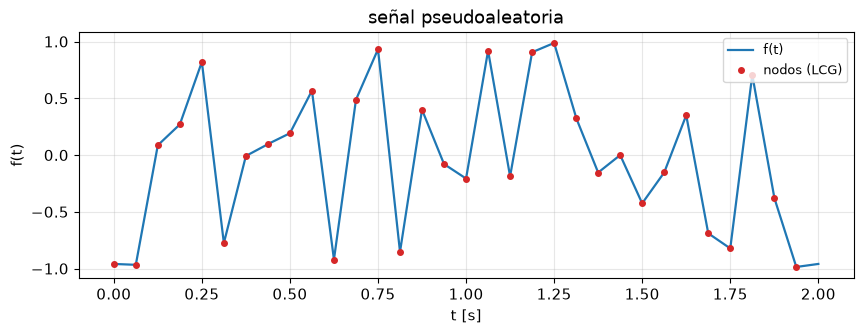

In [10]:
aleatoria = fu.caso_pseudoaleatorio(T_ALEATORIA, N_NODOS, SEMILLA, M, N_MAX_ALEATORIA)
print("x_1..x_5 =", aleatoria["enteros_lcg"][:5])
print("v_1..v_5 =", np.round(aleatoria["valores_nodos"][:5], 6))
fig = fu.dibujar_nodos(aleatoria)

Se calculan los coeficientes hasta $n = 64$ con $M = 4096$ intervalos, los mismos que usa la página interactiva. A diferencia de los casos anteriores, el espectro se extiende por todas las frecuencias; no obstante, las amplitudes decrecen con $n$ porque la señal es continua y sus pendientes están acotadas (los vértices de la interpolación hacen que el decaimiento sea del orden de $1/n^2$).

 n    a_n        b_n
 0  -0.032411   0.000000
 1  -0.335935   0.034623
 2  -0.081997   0.195069
 3  -0.049445  -0.088373
 4  -0.238014   0.090314


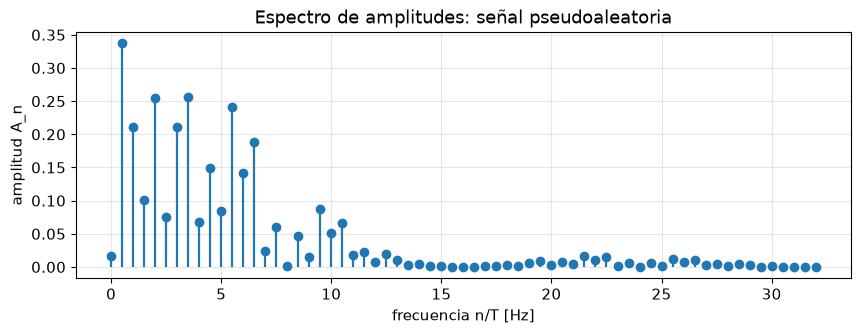

In [11]:
fig = fu.dibujar_espectro(aleatoria)
print(" n    a_n        b_n")
for n in range(5):
    print(f"{n:2d}  {aleatoria['a'][n]: .6f}  {aleatoria['b'][n]: .6f}")

## 4. Reconstrucción

A partir de los coeficientes se construye la suma parcial con $N$ armónicos:

$$
S_N(t) = \frac{a_0}{2} + \sum_{n=1}^{N}\left[a_n\cos(\omega_n t) + b_n\sin(\omega_n t)\right],
$$

y se mide su distancia a la señal con el error eficaz relativo:

$$
e_N = \frac{\mathrm{RMS}(f - S_N)}{\mathrm{RMS}(f)}, \qquad \mathrm{RMS}(g) = \sqrt{\frac{1}{T}\int_0^T g^2\,dt}.
$$

La rejilla de figuras superpone la señal original (gris) y $S_N$ (azul) para $N = 1, 2, 4, 8, 16, 32, 64$. Con pocos armónicos solo se reproduce la tendencia lenta; los detalles de 32 nodos por periodo exigen llegar al armónico 16, que es el que tiene 16 ciclos en $T$.

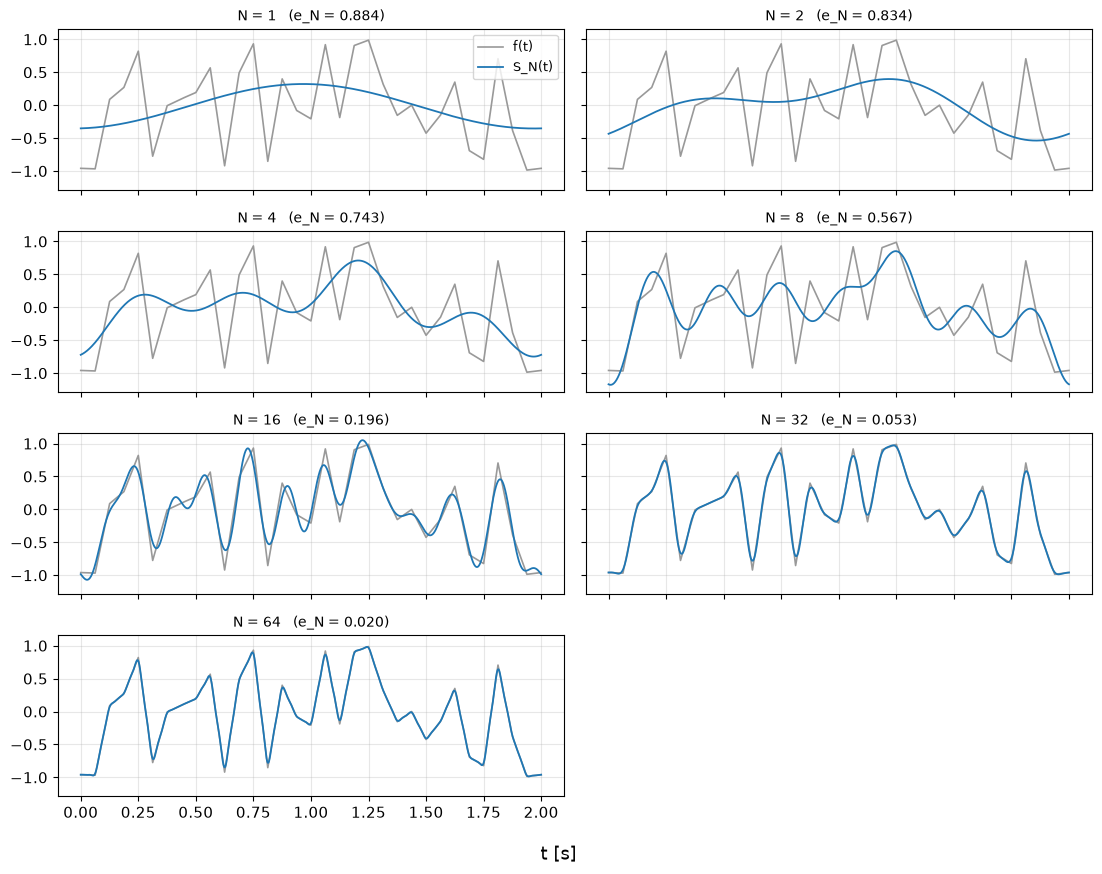

In [12]:
barrido = fu.barrido_reconstruccion(aleatoria, range(0, N_MAX_ALEATORIA + 1))
fig = fu.dibujar_reconstrucciones(aleatoria, barrido, LISTA_N_REJILLA)

La celda siguiente ofrece un deslizador para recorrer $N$ de 0 a 64 si `ipywidgets` está instalado y `USAR_WIDGETS` es `True`. En caso contrario dibuja una lista fija de valores, de modo que el cuaderno funciona igual sin interactividad.

In [13]:
try:
    if not USAR_WIDGETS:
        raise ImportError
    import ipywidgets as widgets

    def ver(N):
        fu.dibujar_una_reconstruccion(aleatoria, barrido, N)
        plt.show()

    widgets.interact(ver, N=widgets.IntSlider(value=8, min=0, max=N_MAX_ALEATORIA, step=1))
except ImportError:
    for N in (3, 12, 24):
        fig = fu.dibujar_una_reconstruccion(aleatoria, barrido, N)

interactive(children=(IntSlider(value=8, description='N', max=64), Output()), _dom_classes=('widget-interact',…

El error $e_N$ decrece de forma monótona con $N$, dado que cada armónico añadido resta su propia energía a la del residuo. En escala logarítmica se aprecia que la caída es rápida hasta $N \approx 16$ y más lenta después, cuando solo quedan por reproducir los vértices de la interpolación.

e_4  = 0.742587
e_8  = 0.566628
e_16 = 0.196074
e_32 = 0.052851
e_64 = 0.020449


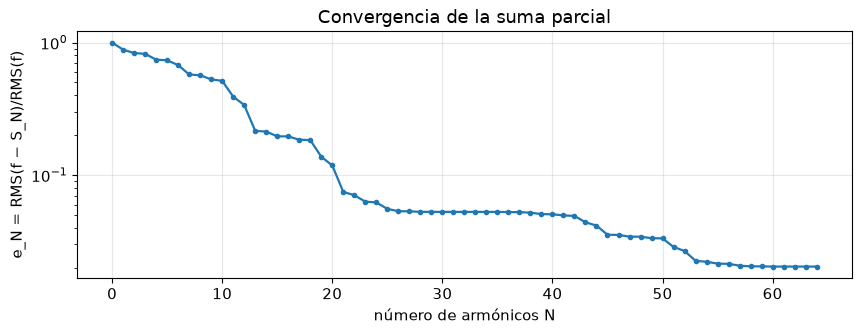

In [14]:
fig = fu.dibujar_error(barrido)
for N in (4, 8, 16, 32, 64):
    print(f"e_{N:<2d} = {barrido['e_rms'][N]:.6f}")

La igualdad de Parseval relaciona la potencia media de la señal con la de sus armónicos:

$$
\frac{1}{T}\int_0^T f^2\,dt = \frac{a_0^2}{4} + \frac{1}{2}\sum_{n=1}^{\infty}\left(a_n^2 + b_n^2\right),
$$

lo que quiere decir que $e_N^2 = 1 - P_N/P$, siendo $P$ la potencia de la señal y $P_N$ la de los $N$ primeros términos. La comprobación numérica se muestra a continuación.

In [15]:
P = barrido["potencia_senal"]
for N in (4, 16, 64):
    P_N = barrido["potencia_serie"][N]
    print(f"N = {N:2d}   P_N/P = {P_N / P:.8f}   1 - e_N² = {1 - barrido['e_rms'][N]**2:.8f}")

N =  4   P_N/P = 0.44856481   1 - e_N² = 0.44856481
N = 16   P_N/P = 0.96155513   1 - e_N² = 0.96155513
N = 64   P_N/P = 0.99958185   1 - e_N² = 0.99958185


Esta descomposición es la base del análisis estructural en el dominio de la frecuencia. Si la carga es $p(t) = \sum_n A_n\sin(\omega_n t + \theta_n)$ y la estructura es lineal, la respuesta es la suma de las respuestas a cada armónico, y cada una se obtiene multiplicando $A_n$ por la función de respuesta en frecuencia (FRF) $H(\omega_n)$ y sumando su desfase. Por tanto, el espectro de la carga, combinado con la FRF, indica directamente qué armónicos se amplifican al acercarse a la frecuencia propia y cuáles son irrelevantes.

## 5. Del cálculo literal a la FFT

La integral literal repite, para cada armónico, un producto y una suma sobre los $M + 1$ puntos de la malla, con un coste del orden de $2(n_{\max}+1)(M+1)$ productos. Cuando la señal es periódica, la regla del trapecio coincide con la suma de los $M$ primeros puntos (el último repite el primero), y esa suma es precisamente la transformada discreta de Fourier:

$$
F_n = \sum_{k=0}^{M-1} f_k\, e^{-i 2\pi n k/M}, \qquad a_n = \frac{2}{M}\operatorname{Re}F_n, \qquad b_n = -\frac{2}{M}\operatorname{Im}F_n,
$$

donde $f_k = f(kT/M)$. La FFT evalúa todos los $F_n$ a la vez con del orden de $(M/2)\log_2 M$ productos complejos. La celda siguiente comprueba que `numpy.fft.rfft`, con ese escalado, reproduce los coeficientes del paso 3 y compara los costes.

Diferencia máxima entre coeficientes: 1.30e-15
Productos (orden de magnitud): integral 532,610   FFT 24,576
Tiempo medio: integral 5.22 ms   FFT 0.146 ms   (cociente ≈ 36)


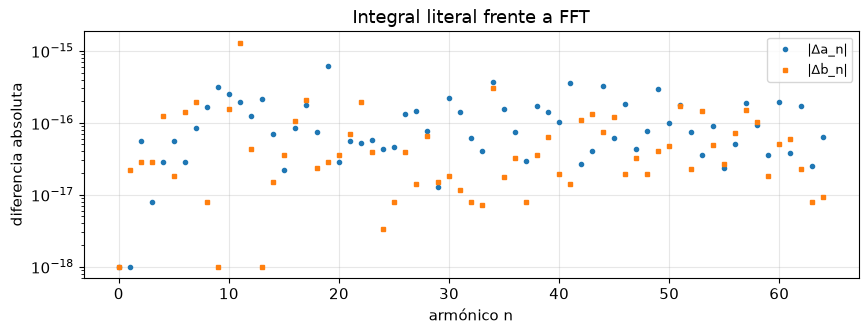

In [16]:
comparacion = fu.comparar_integral_fft(aleatoria)
print(f"Diferencia máxima entre coeficientes: {comparacion['dif_max']:.2e}")
print(f"Productos (orden de magnitud): integral {comparacion['ops_integral']:,}   FFT {comparacion['ops_fft']:,}")
print(f"Tiempo medio: integral {1e3 * comparacion['tiempo_integral']:.2f} ms   "
      f"FFT {1e3 * comparacion['tiempo_fft']:.3f} ms   "
      f"(cociente ≈ {comparacion['tiempo_integral'] / comparacion['tiempo_fft']:.0f})")
fig = fu.dibujar_diferencia_fft(comparacion)

Las diferencias son del orden del error de redondeo, de modo que ambos procedimientos calculan lo mismo. La FFT, sin embargo, obtiene de una vez los $M/2$ coeficientes posibles, mientras que la integral literal solo calcula los que se piden y su coste crece con cada armónico. Cabe señalar que la equivalencia exige que la señal sea periódica en la ventana; con una ventana como la del ejercicio 1.1, el trapecio y la FFT difieren ligeramente porque $f(0) \neq f(T)$.

## 6. Ejercicios propuestos

Los ejercicios siguientes exigen modificar el código, respetando la separación entre cálculo, proceso y dibujo de `fourier.py`:

1. **Onda cuadrada y fenómeno de Gibbs.** Añádase en la sección *1. CÁLCULO* una función `onda_cuadrada(t, T)` que valga $+1$ en la primera mitad del periodo y $-1$ en la segunda, y analícese como en el paso 4. Indíquese qué ocurre junto a los saltos al aumentar $N$: la sobreelongación tiende a un 9 % del salto (unos 0,18 sobre una amplitud unidad) y no desaparece, aunque se estrecha.
2. **Cambio de periodo.** Repítase el paso 3 con `T_ALEATORIA = 4.0` sin cambiar el número de nodos. Indíquese qué ocurre con las frecuencias $n/T$ del espectro y con el número de armónicos necesario para un mismo $e_N$.
3. **Ruido.** Súmese a la señal pseudoaleatoria un ruido de amplitud 0,05 muestreado en cada uno de los $M+1$ puntos (con `np.random.default_rng(0)`, cuidando que el último valor repita el primero). Indíquese en qué zona del espectro aparece el ruido y cómo afecta a $e_N$ para $N$ grande.
4. **Acelerograma de El Centro.** Léase el registro `datos/ElCentro.txt` (El Centro 1940, componente N-S, en g con Δt = 0,02 s) con `fu.leer_registro(ruta, dt_archivo=0.02, factor=9.81)`, tómese como periodo su duración y calcúlense los coeficientes con la FFT. Indíquese en qué banda de frecuencias se concentra la energía y qué periodos propios de estructura resultarían más solicitados.

## Comprobación

La última celda comprueba los resultados principales del cuaderno y guarda en `verificacion.json` las cifras que permiten contrastarlo con la página interactiva.

In [17]:
# Paso 1: solo b_2 sobrevive
assert abs(seno["b"][n_seno] - 1.0) < 1e-9
otros = np.delete(np.abs(seno["b"]), n_seno)
assert np.all(otros < 1e-9) and np.all(np.abs(seno["a"]) < 1e-9)

# Paso 2: amplitudes y fases
for c in COMPONENTES:
    n = int(round(c["frecuencia"] * T_SUMA))
    assert abs(suma["A"][n] - c["amplitud"]) < 1e-9
fase_3hz = suma["fase"][int(round(3.0 * T_SUMA))]
assert abs(fase_3hz - np.pi / 4) < 1e-9

# Paso 5: FFT = integral literal
assert comparacion["dif_max"] < 1e-12

# Parseval
assert abs(barrido["potencia_serie"][64] / barrido["potencia_senal"]
           - (1 - barrido["e_rms"][64] ** 2)) < 1e-10

verificacion = {
    "lcg_x1_x5": aleatoria["enteros_lcg"][:5],
    "lcg_v1_v5": [float(v) for v in aleatoria["valores_nodos"][:5]],
    "paso3_a0_a4": [float(x) for x in aleatoria["a"][:5]],
    "paso3_b0_b4": [float(x) for x in aleatoria["b"][:5]],
    "e_N": {str(N): float(barrido["e_rms"][N]) for N in (4, 8, 16, 32, 64)},
    "M": M,
}
Path("verificacion.json").write_text(json.dumps(verificacion, indent=2))
print(json.dumps(verificacion, indent=2))

print("\nTodas las comprobaciones son correctas.")

{
  "lcg_x1_x5": [
    87628868,
    71072467,
    2332836374,
    2726892157,
    3908547000
  ],
  "lcg_v1_v5": [
    -0.9591946285218,
    -0.9669043035246432,
    0.08631158899515867,
    0.2698081121779978,
    0.8200590275228024
  ],
  "paso3_a0_a4": [
    -0.03241055039688945,
    -0.33593496231831965,
    -0.0819968888030532,
    -0.04944545234141423,
    -0.2380144609592178
  ],
  "paso3_b0_b4": [
    0.0,
    0.03462259785156255,
    0.1950687569329251,
    -0.08837340205368534,
    0.09031394416050588
  ],
  "e_N": {
    "4": 0.7425868260644528,
    "8": 0.5666278726380138,
    "16": 0.19607363159723765,
    "32": 0.05285106560466333,
    "64": 0.02044866994240511
  },
  "M": 4096
}

Todas las comprobaciones son correctas.
